# FP-Growth — Demo & Thực nghiệm (Chương 4)
Notebook minh hoạ thuật toán và hiển thị đồ thị thực nghiệm.

In [1]:
import Pkg; Pkg.activate(joinpath(@__DIR__, ".."))
using FrequentItemsetMining

  Activating project at `~/Documents/school/25_26_Semester_2/data-mining/lab2`


## 1. Demo trên CSDL đồ chơi

In [2]:
tx = collect(values(load_transactions(joinpath(@__DIR__, "..", "data", "toy", "test_1.txt"))))
m = FPGrowthOpt(0.6); fit!(m, tx)
get_frequent_itemsets(m)

Dict{Tuple{Vararg{String}}, Int64} with 9 entries:
  ("2", "5")      => 4
  ("1",)          => 3
  ("2", "3")      => 3
  ("5",)          => 4
  ("2",)          => 4
  ("1", "3")      => 3
  ("2", "3", "5") => 3
  ("3",)          => 4
  ("3", "5")      => 3

## 2. Sinh đồ thị thực nghiệm từ CSV

In [3]:
include(joinpath(@__DIR__, "..", "experiments", "make_figures.jl"))

Figures written to /home/lesliu/Documents/school/25_26_Semester_2/data-mining/lab2/experiments/figures


## 3. Hiển thị đồ thị

**count_T10I4D100K.png**

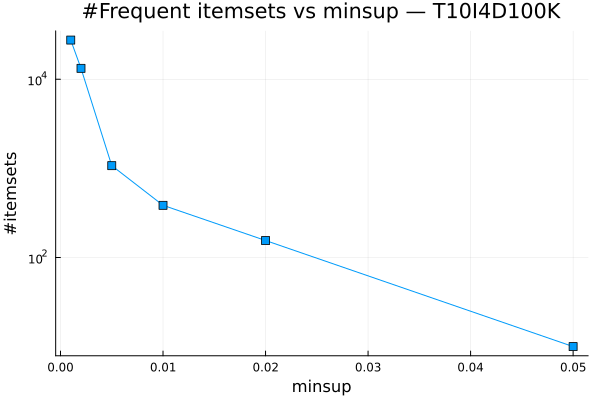

**count_accidents.png**

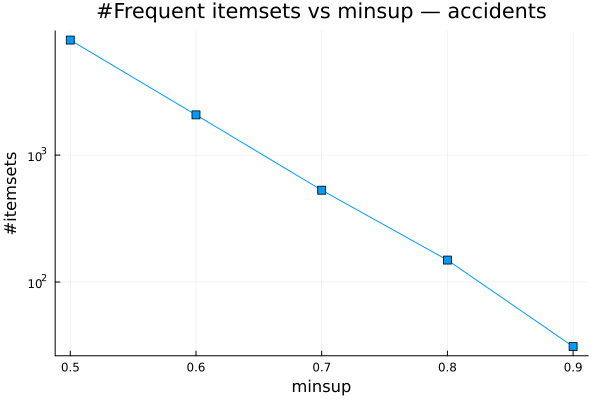

**count_chess.png**

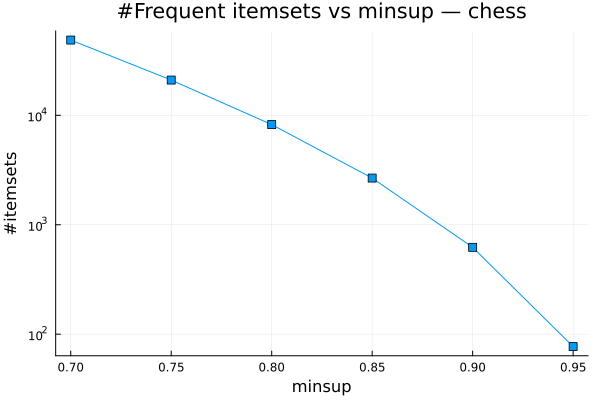

**count_mushrooms.png**

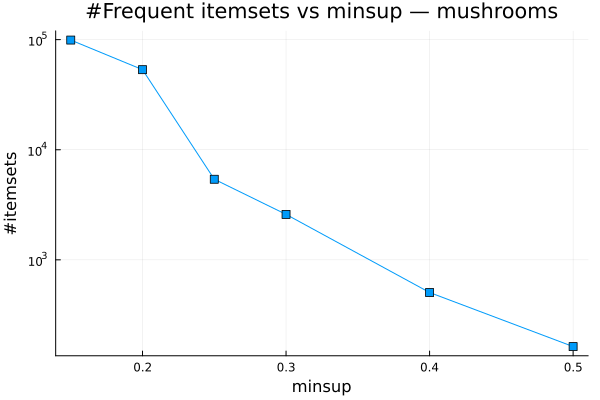

**count_retail.png**

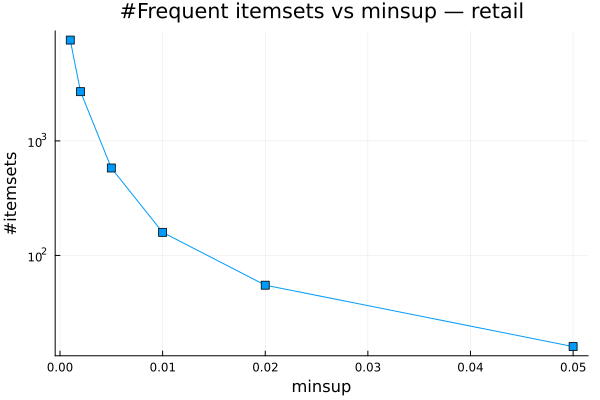

**memory.png**

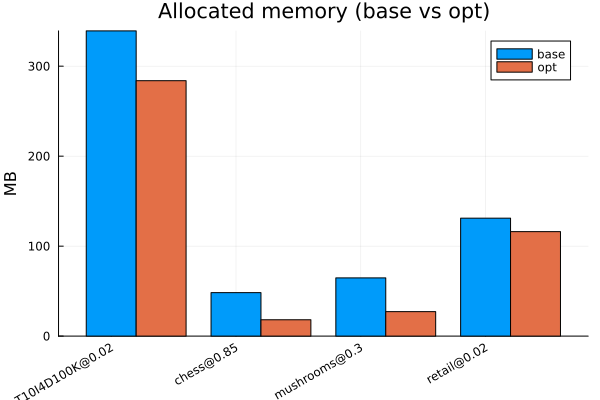

**scalability.png**

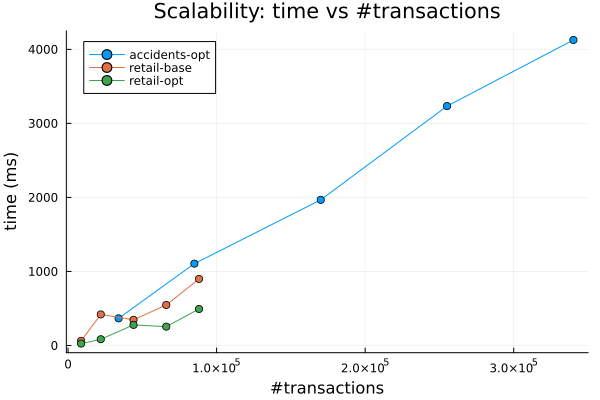

**time_T10I4D100K.png**

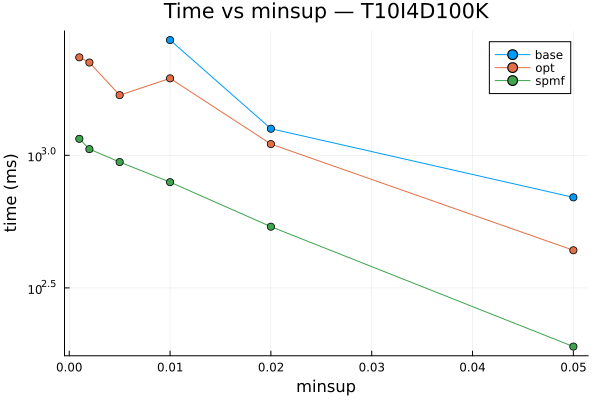

**time_accidents.png**

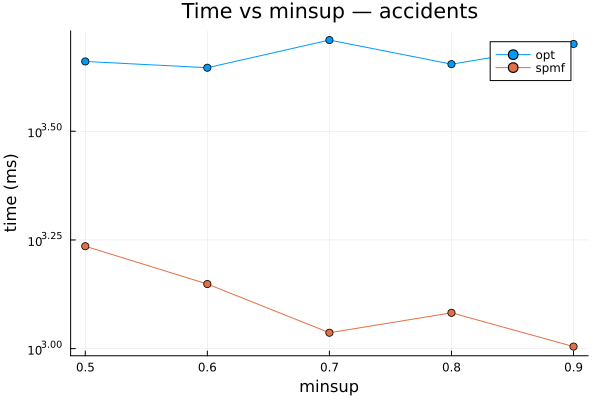

**time_chess.png**

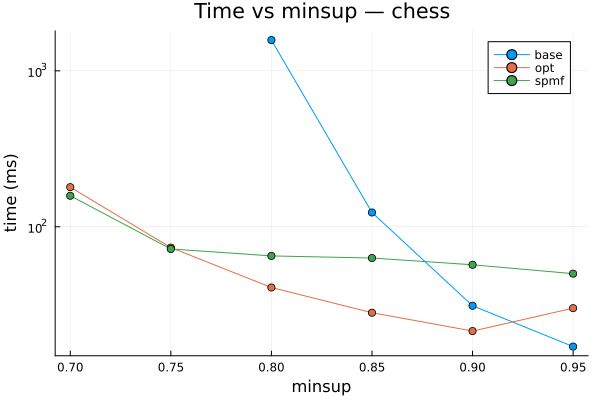

**time_mushrooms.png**

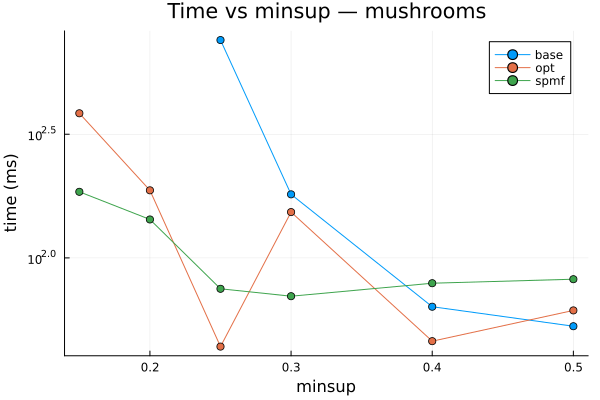

**time_retail.png**

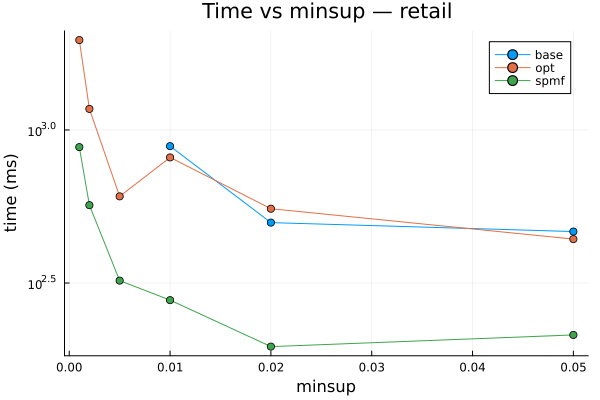

**txnlen.png**

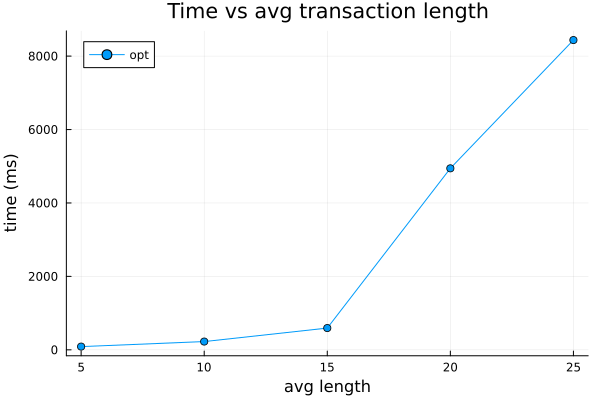

In [4]:
figdir = joinpath(@__DIR__, "..", "experiments", "figures")
for f in sort(readdir(figdir))
    endswith(f, ".png") || continue
    display("text/markdown", "**$f**")
    display(MIME("image/png"), read(joinpath(figdir, f)))
end

## 4. Ứng dụng: Market Basket Analysis (groceries)

In [5]:
include(joinpath(@__DIR__, "..", "experiments", "application.jl"))

Groceries: 9835 giao dịch, minsup=0.01, minconf=0.2
#frequent itemsets=333, #rules(lift>1)=231

Top-10 luật theo lift:
{citrus fruit, other vegetables} => {root vegetables}  sup=0.0104 conf=0.359 lift=3.295
{other vegetables, yogurt} => {whipped/sour cream}  sup=0.0102 conf=0.234 lift=3.267
{other vegetables, tropical fruit} => {root vegetables}  sup=0.0123 conf=0.343 lift=3.145
{beef} => {root vegetables}  sup=0.0174 conf=0.331 lift=3.040
{citrus fruit, root vegetables} => {other vegetables}  sup=0.0104 conf=0.586 lift=3.030
{root vegetables, tropical fruit} => {other vegetables}  sup=0.0123 conf=0.585 lift=3.021
{other vegetables, whole milk} => {root vegetables}  sup=0.0232 conf=0.310 lift=2.842
{root vegetables} => {other vegetables, whole milk}  sup=0.0232 conf=0.213 lift=2.842
{butter} => {other vegetables, whole milk}  sup=0.0115 conf=0.207 lift=2.771
{curd, whole milk} => {yogurt}  sup=0.0101 conf=0.385 lift=2.761

CSV: /home/lesliu/Documents/school/25_26_Semester_2/data-mining

231-element Vector{AssociationRule}:
 AssociationRule(["citrus fruit", "other vegetables"], ["root vegetables"], 0.010371123538383325, 0.3591549295774648, 3.295045459323103)
 AssociationRule(["other vegetables", "yogurt"], ["whipped/sour cream"], 0.010167768174885612, 0.234192037470726, 3.267061969538426)
 AssociationRule(["other vegetables", "tropical fruit"], ["root vegetables"], 0.012302999491611592, 0.34277620396600567, 3.144779819035136)
 AssociationRule(["beef"], ["root vegetables"], 0.017386883579054397, 0.3313953488372093, 3.0403668431100312)
 AssociationRule(["citrus fruit", "root vegetables"], ["other vegetables"], 0.010371123538383325, 0.5862068965517241, 3.0296084222733612)
 AssociationRule(["root vegetables", "tropical fruit"], ["other vegetables"], 0.012302999491611592, 0.5845410628019324, 3.020999134344196)
 AssociationRule(["other vegetables", "whole milk"], ["root vegetables"], 0.023182511438739197, 0.30978260869565216, 2.84208204899416)
 AssociationRule(["root vegetab

## 5. Kiểm chứng toàn bộ kết quả Chương 4 & 5

Đối chiếu số frequent itemset của bản FP-Growth tối ưu với các giá trị đã lưu trong báo cáo (`experiments/results/timing.csv`, `scalability.csv`, `txnlen.csv`) và số luật kết hợp ở Chương 5. In bảng PASS/FAIL và dòng tổng kết.

In [6]:
include(joinpath(@__DIR__, "..", "experiments", "verify_results.jl"))

== Chương 4 — số frequent itemset theo minsup (timing.csv) ==
  [PASS] T10I4D100K minsup=0.001                          got=27532   expect=27532  
  [PASS] T10I4D100K minsup=0.002                          got=13255   expect=13255  
  [PASS] T10I4D100K minsup=0.005                          got=1073    expect=1073   
  [PASS] T10I4D100K minsup=0.01                           got=385     expect=385    
  [PASS] T10I4D100K minsup=0.02                           got=155     expect=155    
  [PASS] T10I4D100K minsup=0.05                           got=10      expect=10     
  [PASS] accidents minsup=0.5                             got=8057    expect=8057   
  [PASS] accidents minsup=0.6                             got=2074    expect=2074   
  [PASS] accidents minsup=0.7                             got=529     expect=529    
  [PASS] accidents minsup=0.8                             got=149     expect=149    
  [PASS] accidents minsup=0.9                             got=31      expect=31     
  [

true